C:\Users\anshs\AppData\Local\Temp\ipykernel_7544\1483297337.py:10: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


** Original Data **
           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2020-01-31         M                             5.48   
1  Andhra Pradesh 2020-02-29         M                             5.83   
2  Andhra Pradesh 2020-03-31         M                             5.79   
3  Andhra Pradesh 2020-04-30         M                            20.51   
4  Andhra Pradesh 2020-05-31         M                            17.43   

   Estimated Employed  Estimated Labour Participation Rate (%) Region.1  \
0            16635535                                    41.02    South   
1            16545652                                    40.90    South   
2            15881197                                    39.18    South   
3            11336911                                    33.10    South   
4            12988845                                    36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129     79.74  
2  

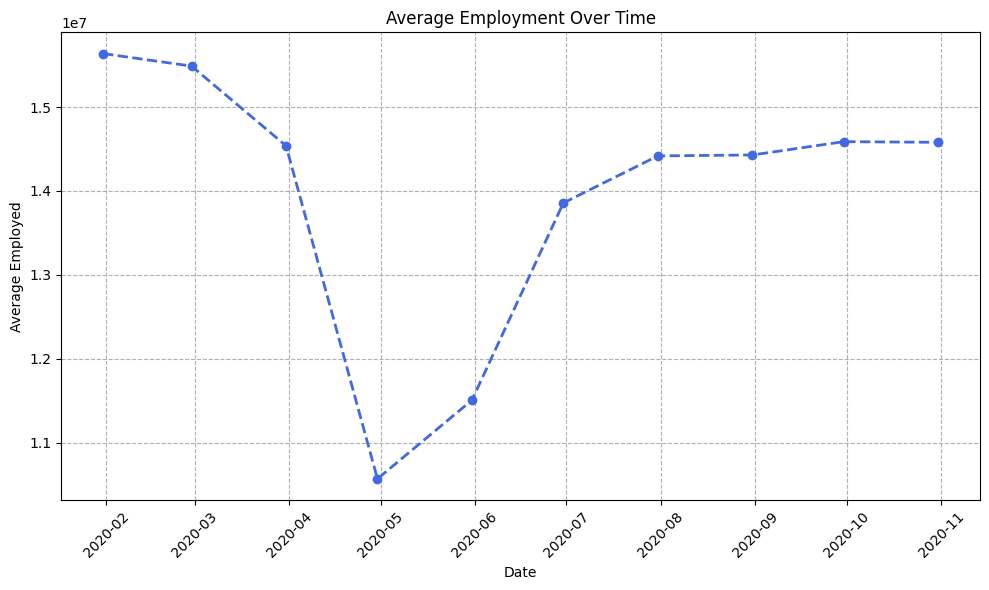

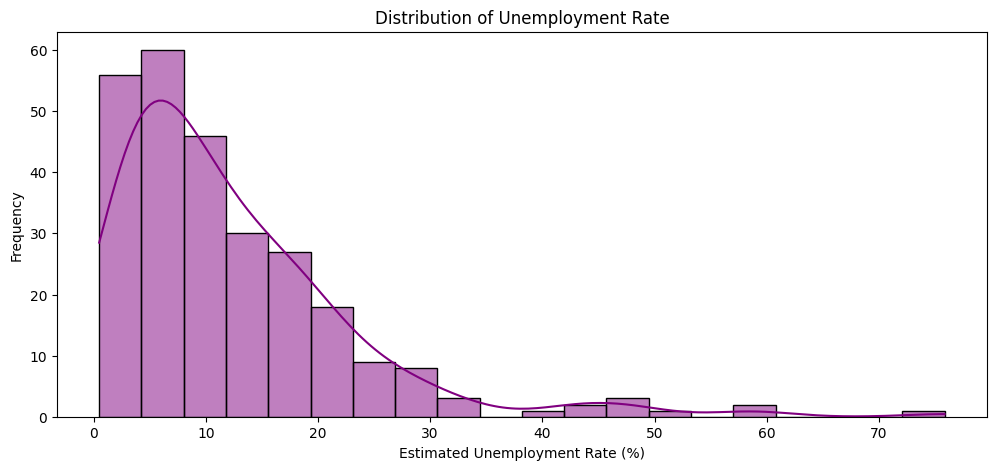

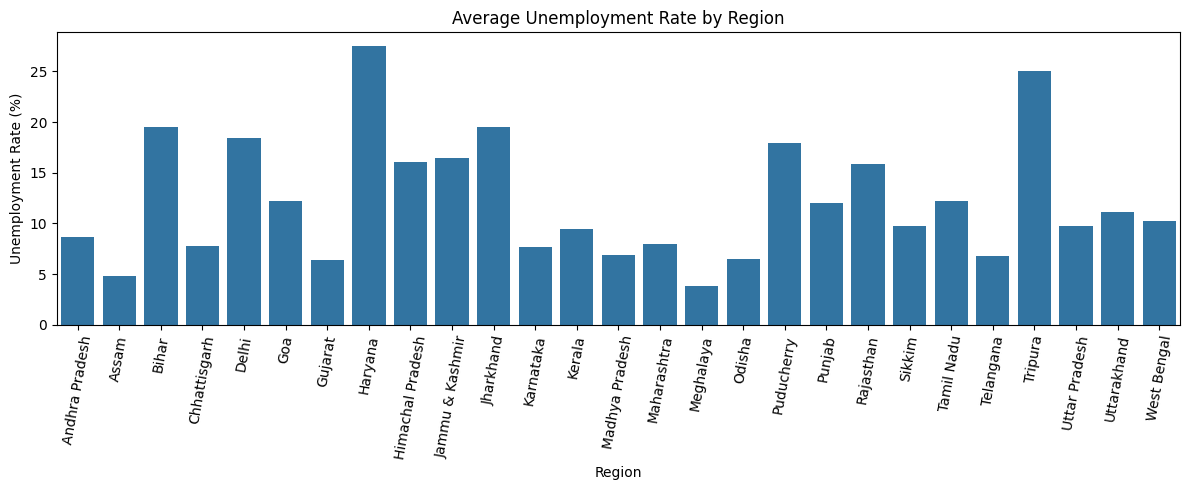

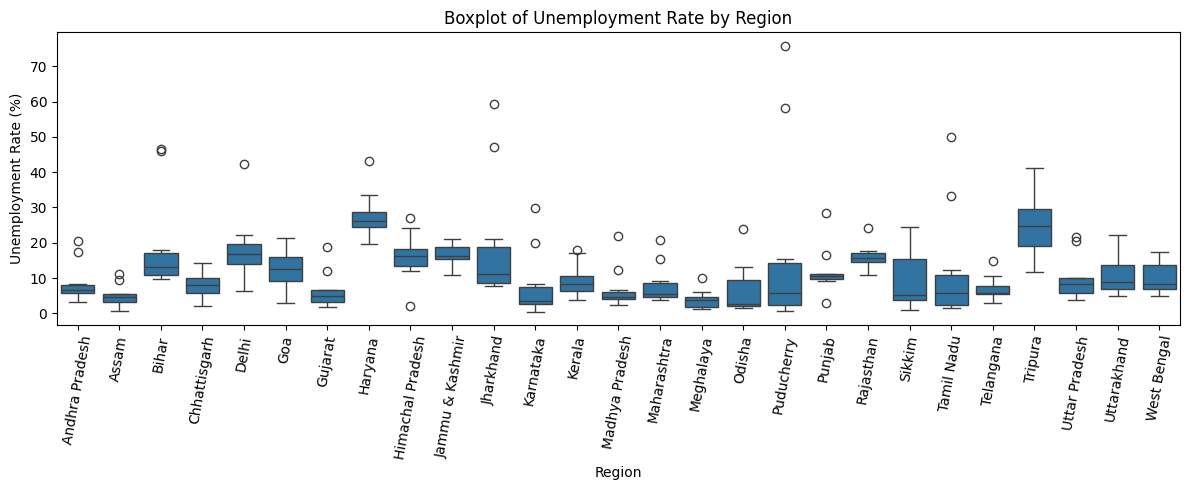

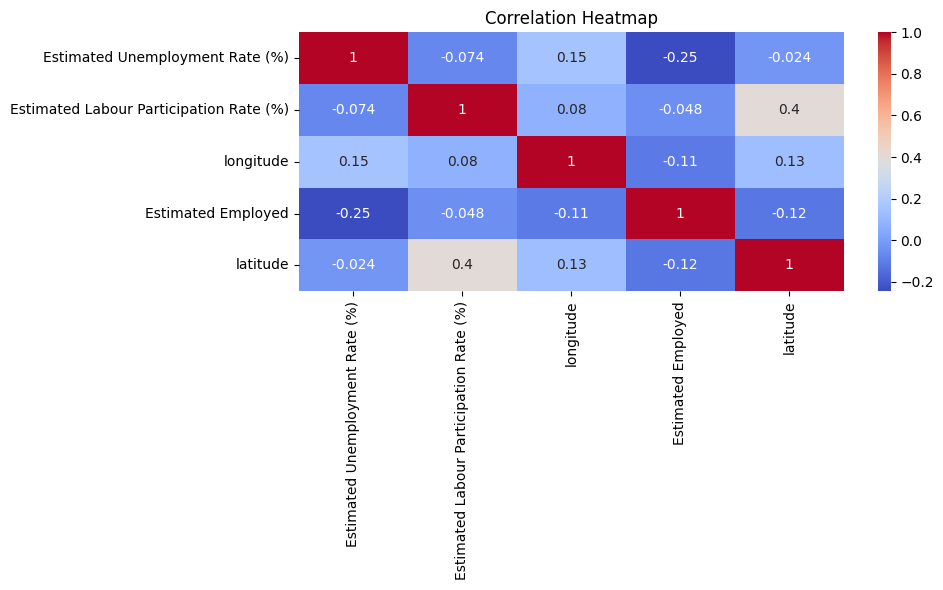

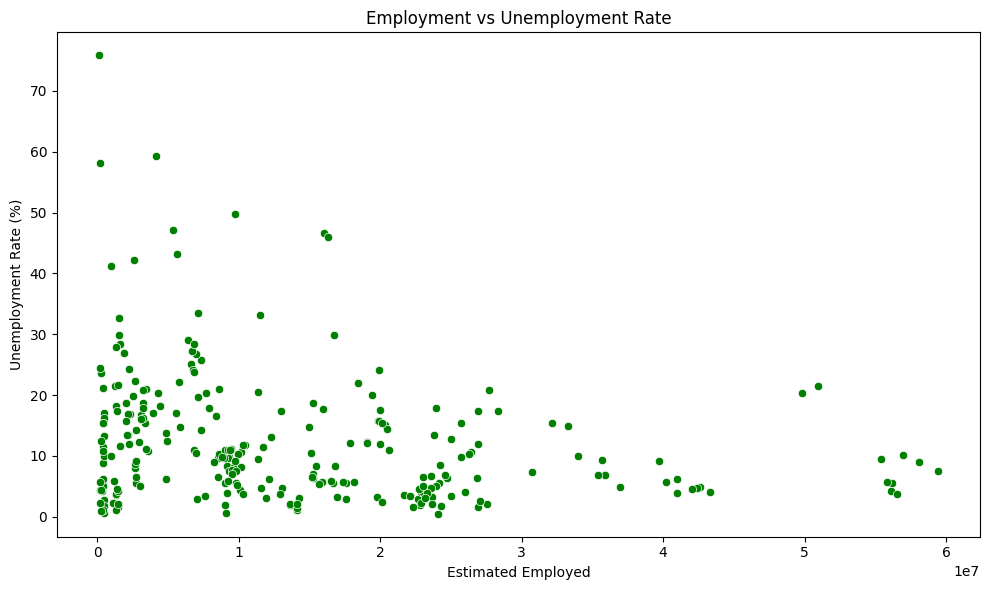

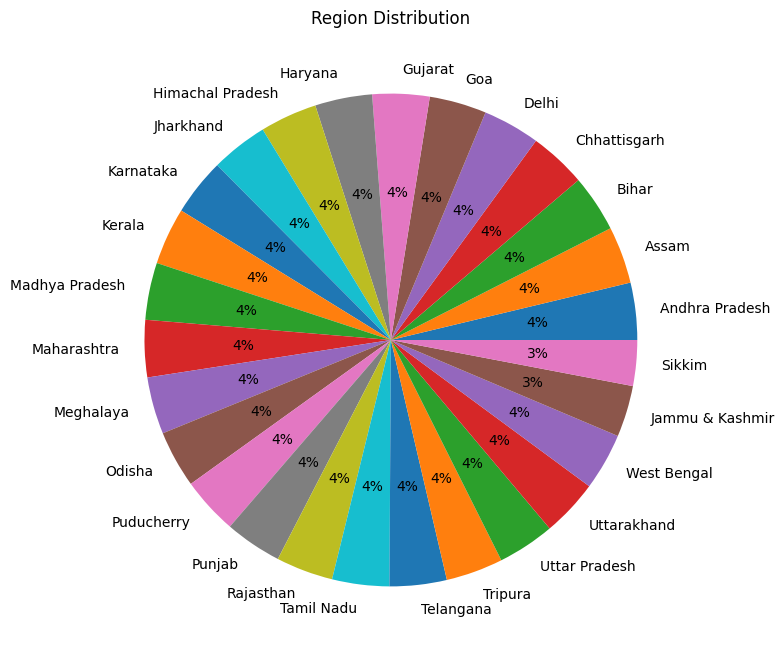

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file = r"C:\Users\anshs\OneDrive\Desktop\project\Unemployment analysis\Unemployment_Rate_upto_11_2020.csv"
df = pd.read_csv(file)

df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"])

print("** Original Data **")
print(df.head())
df.info()
print(df.describe())
print(df.columns)
print(df.isnull().sum())
print(df.duplicated().sum())

df.fillna({
    "Estimated Unemployment Rate (%)": 0,
    "Estimated Employed": df["Estimated Employed"].mean()
}, inplace=True)

print("Average unemployment rate :", df["Estimated Unemployment Rate (%)"].mean())
print("Maximum unemployment rate :", df["Estimated Unemployment Rate (%)"].max())
print("Minimum unemployment rate :", df["Estimated Unemployment Rate (%)"].min())
print("Average Labour Participation rate :", df["Estimated Labour Participation Rate (%)"].mean())

daily_avg = df.groupby("Date")["Estimated Employed"].mean()

plt.figure(figsize=(10, 6))
plt.plot(daily_avg.index, daily_avg.values, color="royalblue", linewidth=2, linestyle="--", marker="o")
plt.title("Average Employment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Employed")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df["Estimated Unemployment Rate (%)"], bins=20, kde=True, color="purple")
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(x="Region", y="Estimated Unemployment Rate (%)", data=region_avg)
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x="Region", y="Estimated Unemployment Rate (%)", data=df)
plt.title("Boxplot of Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df[[
    "Estimated Unemployment Rate (%)",
    "Estimated Labour Participation Rate (%)",
    "longitude",
    "Estimated Employed",
    "latitude"
]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x="Estimated Employed", y="Estimated Unemployment Rate (%)", data=df, color="green")
plt.title("Employment vs Unemployment Rate")
plt.xlabel("Estimated Employed")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

region_count = df["Region"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(region_count, labels=region_count.index, autopct="%1.0f%%")
plt.title("Region Distribution")
plt.show()
